In [1]:
pip install tensorflow keras opencv-python matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [11]:
# Dataset path
dataset_path = "train"

In [9]:
# Image size
IMG_SIZE = 224
BATCH_SIZE = 32

In [12]:
# Data preprocessing
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)


Found 2321 images belonging to 4 classes.
Found 579 images belonging to 4 classes.


In [13]:

# Load Pretrained Model
base_model = MobileNetV2(weights='imagenet',
                         include_top=False,
                         input_shape=(IMG_SIZE, IMG_SIZE, 3))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [14]:
# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False


In [15]:
# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [16]:
# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
# Train
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)


Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.8048 - loss: 0.3894 - val_accuracy: 0.7029 - val_loss: 0.5735
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.9095 - loss: 0.1991 - val_accuracy: 0.7185 - val_loss: 0.5651
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.9517 - loss: 0.1326 - val_accuracy: 0.7807 - val_loss: 0.5293
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.9677 - loss: 0.0998 - val_accuracy: 0.7271 - val_loss: 0.6405
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.9703 - loss: 0.0864 - val_accuracy: 0.7271 - val_loss: 0.6928
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.9815 - loss: 0.0640 - val_accuracy: 0.7271 - val_loss: 0.7385
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.9854 - loss: 0.0540 - val_accuracy: 0.7582 - val_loss: 0.6645
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 67s 908ms/step - accuracy: 0.9858 - loss: 0.0454 - val_accuracy: 0.7513 - 

In [18]:
# Save model
model.save("drowsiness_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


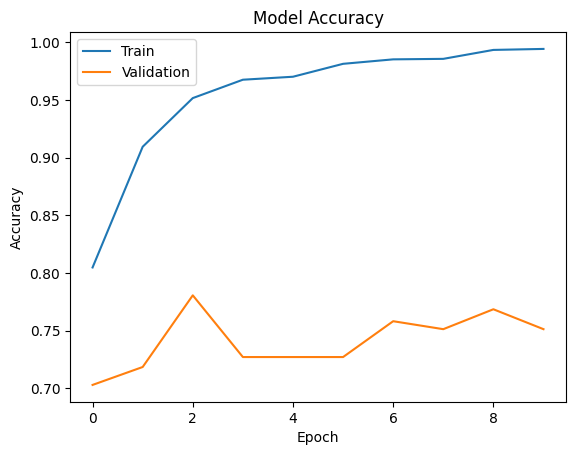

In [19]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(['Train','Validation'])
plt.show()

In [24]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

model = load_model("drowsiness_model.h5")

classes = ['Closed','Open','no_yawn','yawn']

img = cv2.imread("test2.jpg")
img = cv2.resize(img,(224,224))
img = img/255.0
img = np.reshape(img,[1,224,224,3])

prediction = model.predict(img)

print("Prediction:", classes[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 907ms/step
Prediction: Closed


In [25]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

model = load_model("drowsiness_model.h5")

classes = ['Closed','Open','no_yawn','yawn']

img = cv2.imread("test3.jpg")
img = cv2.resize(img,(224,224))
img = img/255.0
img = np.reshape(img,[1,224,224,3])

prediction = model.predict(img)

print("Prediction:", classes[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 865ms/step
Prediction: Open


In [26]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

model = load_model("drowsiness_model.h5")

classes = ['Closed','Open','no_yawn','yawn']

img = cv2.imread("test4.jpg")
img = cv2.resize(img,(224,224))
img = img/255.0
img = np.reshape(img,[1,224,224,3])

prediction = model.predict(img)

print("Prediction:", classes[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 895ms/step
Prediction: no_yawn


In [27]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

model = load_model("drowsiness_model.h5")

classes = ['Closed','Open','no_yawn','yawn']

img = cv2.imread("test5.jpg")
img = cv2.resize(img,(224,224))
img = img/255.0
img = np.reshape(img,[1,224,224,3])

prediction = model.predict(img)

print("Prediction:", classes[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 837ms/step
Prediction: yawn
